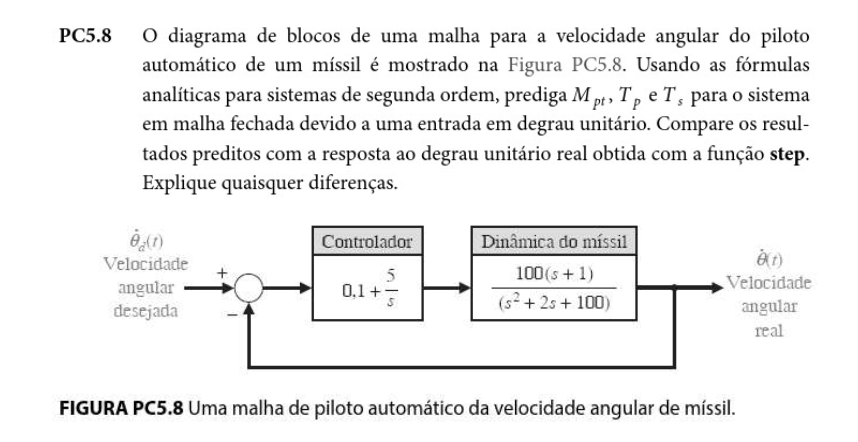

PROBLEMA PC5.8 - ANÁLISE DO PILOTO AUTOMÁTICO DE MÍSSIL

(1) COMPONENTES DO SISTEMA:
-------------------------------------------------------------------------------------

Controlador: G_c(s) = 0.1 + 5/s =
<TransferFunction>: sys[16]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.1 s + 5
  ---------
      s

Dinâmica do Míssil: G_p(s) = 100(s+1)/(s² + 2s + 100) =
<TransferFunction>: sys[17]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    100 s + 100
  ---------------
  s^2 + 2 s + 100

Função de Transferência em Malha Aberta:
L(s) = G_c(s) * G_p(s) =
<TransferFunction>: sys[18]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  10 s^2 + 510 s + 500
  --------------------
  s^3 + 2 s^2 + 100 s

Numerador de L(s): [ 10. 510. 500.]
Denominador de L(s): [array([  1,   2, 100,   0])]

FUNÇÃO DE TRANSFERÊNCIA EM MALHA FECHADA:
T(s) = L(s)/(1 + L(s)) = Θ̂(s)/Θ̇_d(s) =
<TransferFunction>: sys[20]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

     10 s^2 + 510 s + 500
  --------------------------
  s

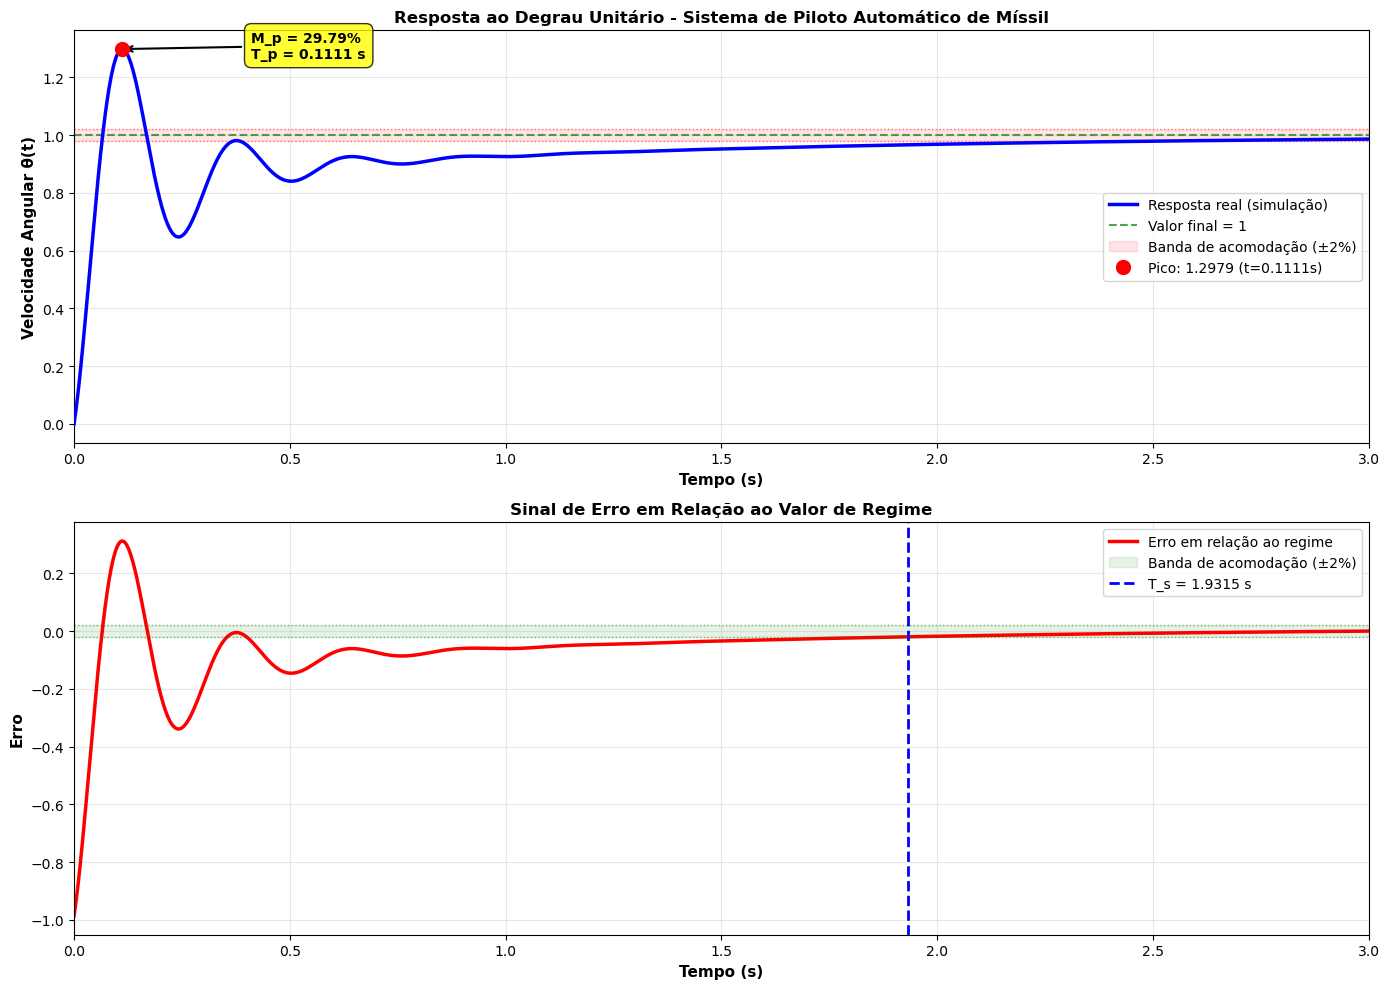


EXPLICAÇÃO DAS DIFERENÇAS:

O sistema completo é de QUARTA ORDEM (4 pólos), não de segunda ordem:
  - O controlador introduz um integrador (pólo em s=0)
  - O processo (dinâmica do míssil) contribui com 2 pólos adicionais

As fórmulas de segunda ordem foram aplicadas aos PÓLOS DOMINANTES:
  - Os pólos dominantes são um par conjugado complexo
  - Esses pólos determinam o comportamento transiente principal da resposta

Razões para as diferenças observadas:
  1. EFEITO DOS PÓLOS NÃO-DOMINANTES: Os outros dois pólos (menos dominantes)
     afetam a resposta transiente e o regime estacionário
  2. SISTEMA DE ORDEM SUPERIOR: Como o sistema é de 4ª ordem e não 2ª,
     a aproximação é apenas uma estimativa
  3. O INTEGRADOR: Garante erro zero em regime para entrada em degrau,
     mas afeta a dinâmica transiente

A aproximação de segunda ordem ainda é ÚTIL porque:
  ✓ Fornece uma estimativa rápida dos parâmetros principais
  ✓ O comportamento é dominado pelos pólos complexos
  ✓ Permite comp

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct
from scipy import signal

print("=" * 85)
print("PROBLEMA PC5.8 - ANÁLISE DO PILOTO AUTOMÁTICO DE MÍSSIL")
print("=" * 85)

# Define the system components from the block diagram
# Controller: G_c(s) = 0.1 + 5/s = (0.1s + 5)/s
# Missile dynamics: G_p(s) = 100(s+1)/(s² + 2s + 100)
# Negative feedback

print("\n(1) COMPONENTES DO SISTEMA:")
print("-" * 85)

# Controller transfer function: G_c(s) = 0.1 + 5/s
num_Gc = [0.1, 5]  # 0.1s + 5
den_Gc = [1, 0]    # s

Gc = ct.TransferFunction(num_Gc, den_Gc)
print("\nControlador: G_c(s) = 0.1 + 5/s =")
print(Gc)

# Missile dynamics: G_p(s) = 100(s+1)/(s² + 2s + 100)
num_Gp = [100, 100]        # 100s + 100 = 100(s+1)
den_Gp = [1, 2, 100]       # s² + 2s + 100

Gp = ct.TransferFunction(num_Gp, den_Gp)
print("\nDinâmica do Míssil: G_p(s) = 100(s+1)/(s² + 2s + 100) =")
print(Gp)

# Calculate open-loop transfer function: L(s) = G_c(s) * G_p(s)
L = Gc * Gp
print("\nFunção de Transferência em Malha Aberta:")
print("L(s) = G_c(s) * G_p(s) =")
print(L)

# Extract numerator and denominator of L(s)
num_L, den_L = ct.tfdata(L)
num_L = num_L[0][0]
den_L = den_L[0]

print("\nNumerador de L(s):", num_L)
print("Denominador de L(s):", den_L)

# Calculate closed-loop transfer function: T(s) = L(s)/(1 + L(s))
T = ct.feedback(L)

print("\n" + "=" * 85)
print("FUNÇÃO DE TRANSFERÊNCIA EM MALHA FECHADA:")
print("=" * 85)
print("T(s) = L(s)/(1 + L(s)) = Θ̂(s)/Θ̇_d(s) =")
print(T)

# Extract numerator and denominator of T(s)
num_T, den_T = ct.tfdata(T)
num_T = num_T[0][0]
den_T_flat = np.asarray(den_T[0]).flatten()

print("\nNumerador de T(s):", num_T)
print("Denominador de T(s):", den_T_flat)

# Analyze the system order and extract second-order characteristics
print("\n" + "=" * 85)
print("ANÁLISE DO SISTEMA:")
print("=" * 85)

# The denominator should be approximately s⁴ + ...
# Check if we can approximate as second-order using dominant poles
poles = np.roots(den_T_flat)
print("\nPólos do sistema em malha fechada:")
for i, pole in enumerate(poles):
    if np.isreal(pole):
        print(f"  Pólo {i+1}: {pole.real:.6f}")
    else:
        print(f"  Pólo {i+1}: {pole.real:.6f} ± j{abs(pole.imag):.6f}")

# Find dominant poles (complex conjugate pair with smallest real part in magnitude)
complex_poles = poles[np.iscomplex(poles)]
if len(complex_poles) > 0:
    # Sort by distance from imaginary axis (smallest real part in magnitude)
    complex_poles_sorted = sorted(complex_poles, key=lambda p: abs(p.real))
    dominant_pole = complex_poles_sorted[0]
    
    # Extract ωn and ζ from dominant complex poles
    omega_n_est = abs(dominant_pole)
    zeta_est = -dominant_pole.real / omega_n_est
    
    print(f"\nPólos dominantes (conjugado complexo):")
    print(f"  s = -{dominant_pole.real:.6f} ± j{abs(dominant_pole.imag):.6f}")
    print(f"\nParâmetros equivalentes de segunda ordem (pólos dominantes):")
    print(f"  ωn (frequência natural estimada) = {omega_n_est:.6f} rad/s")
    print(f"  ζ (amortecimento relativo estimado) = {zeta_est:.6f}")
else:
    print("\nNenhum par de pólos complexos encontrado para aproximação de segunda ordem.")

# Calculate theoretical second-order response parameters
print("\n" + "=" * 85)
print("PREDIÇÃO USANDO FÓRMULAS DE SEGUNDA ORDEM:")
print("=" * 85)

if zeta_est < 1:  # Underdamped
    # Maximum overshoot: M_p = e^(-ζπ/√(1-ζ²))
    sqrt_term = np.sqrt(1 - zeta_est**2)
    Mp_theoretical = np.exp(-zeta_est * np.pi / sqrt_term)
    Mp_percent = Mp_theoretical * 100
    
    # Time to peak: T_p = π/(ωn*√(1-ζ²))
    Tp_theoretical = np.pi / (omega_n_est * sqrt_term)
    
    # Settling time (2%): T_s = 4/(ζ*ωn)
    Ts_theoretical = 4 / (zeta_est * omega_n_est)
    
    print(f"\nParâmetros teóricos de segunda ordem:")
    print(f"  Máximo percentual de ultrapassagem:")
    print(f"    M_p = e^(-ζπ/√(1-ζ²)) = e^(-{zeta_est:.6f}*π/{sqrt_term:.6f})")
    print(f"        = e^({-zeta_est*np.pi/sqrt_term:.6f})")
    print(f"        = {Mp_theoretical:.6f}")
    print(f"    M_p = {Mp_percent:.2f}%")
    
    print(f"\n  Tempo até o pico:")
    print(f"    T_p = π/(ωn*√(1-ζ²)) = π/({omega_n_est:.6f}*{sqrt_term:.6f})")
    print(f"        = {Tp_theoretical:.6f} s")
    
    print(f"\n  Tempo de acomodação (2%):")
    print(f"    T_s = 4/(ζ*ωn) = 4/({zeta_est:.6f}*{omega_n_est:.6f})")
    print(f"        = {Ts_theoretical:.6f} s")
else:
    Mp_percent = 0
    Tp_theoretical = None
    Ts_theoretical = 4 / (zeta_est * omega_n_est)
    print(f"\nSistema superamortecido (ζ ≥ 1)")

# Part (b): Simulate step response
print("\n" + "=" * 85)
print("(b) RESPOSTA AO DEGRAU UNITÁRIO - ANÁLISE REAL:")
print("=" * 85)

t = np.linspace(0, 3, 2000)
t_out, y = ct.step_response(T, T=t)

# Find the peak (overshoot)
peak_idx = np.argmax(y)
peak_value = y[peak_idx]
peak_time = t_out[peak_idx]

# Calculate real percent overshoot
Mp_percent_real = (peak_value - 1) * 100  # Final value for unit step is 1

# Find settling time (2% criterion)
final_value = y[-1]
settling_time_idx = None
for i in range(len(y) - 1, 0, -1):
    if abs(y[i] - final_value) > 0.02 * abs(final_value):
        settling_time_idx = i
        break

if settling_time_idx:
    settling_time_real = t_out[settling_time_idx]
else:
    settling_time_real = t_out[-1]

print(f"\nRESULTADOS DA SIMULAÇÃO:")
print(f"  Valor final (regime estacionário): {final_value:.6f}")
print(f"  Valor de pico: {peak_value:.6f}")
print(f"  Tempo de pico: {peak_time:.6f} s")
print(f"  Percentual de ultrapassagem (real): M_p = {Mp_percent_real:.2f}%")
print(f"  Tempo de acomodação (2%, real): T_s ≈ {settling_time_real:.6f} s")

# Comparison
print("\n" + "=" * 85)
print("COMPARAÇÃO - PREDIÇÃO (2ª ORDEM) vs RESPOSTA REAL:")
print("=" * 85)

print(f"\n{'Parâmetro':<40} {'Teórico (2ª ord.)':<20} {'Real':<20} {'Diferença':<15}")
print("-" * 95)
print(f"{'Máximo percentual de ultrapassagem':<40} {Mp_percent:>18.2f}% {Mp_percent_real:>18.2f}% {abs(Mp_percent-Mp_percent_real):>13.2f}%")
print(f"{'Tempo de pico (s)':<40} {Tp_theoretical:>18.6f} {peak_time:>18.6f} {abs(Tp_theoretical-peak_time):>13.6f}")
print(f"{'Tempo de acomodação 2% (s)':<40} {Ts_theoretical:>18.6f} {settling_time_real:>18.6f} {abs(Ts_theoretical-settling_time_real):>13.6f}")

# Plot comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Step response
ax1 = axes[0]
ax1.plot(t_out, y, 'b-', linewidth=2.5, label='Resposta real (simulação)', zorder=3)
ax1.axhline(y=1, color='g', linestyle='--', linewidth=1.5, alpha=0.7, label='Valor final = 1')
ax1.axhline(y=1.02, color='r', linestyle=':', linewidth=1, alpha=0.5)
ax1.axhline(y=0.98, color='r', linestyle=':', linewidth=1, alpha=0.5)
ax1.fill_between(t_out, 0.98, 1.02, alpha=0.1, color='red', label='Banda de acomodação (±2%)')

# Mark peak
ax1.plot(peak_time, peak_value, 'ro', markersize=10, zorder=4, label=f'Pico: {peak_value:.4f} (t={peak_time:.4f}s)')
ax1.annotate(f'M_p = {Mp_percent_real:.2f}%\nT_p = {peak_time:.4f} s', 
            xy=(peak_time, peak_value), 
            xytext=(peak_time + 0.3, peak_value - 0.03),
            fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.8),
            arrowprops=dict(arrowstyle='->', lw=1.5))

ax1.grid(True, alpha=0.3)
ax1.set_xlabel('Tempo (s)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Velocidade Angular θ̇(t)', fontsize=11, fontweight='bold')
ax1.set_title('Resposta ao Degrau Unitário - Sistema de Piloto Automático de Míssil', 
             fontsize=12, fontweight='bold')
ax1.legend(fontsize=10, loc='right')
ax1.set_xlim(0, 3)

# Plot 2: Error or derivative
ax2 = axes[1]
# Calculate error from final value
error = y - final_value
ax2.plot(t_out, error, 'r-', linewidth=2.5, label='Erro em relação ao regime')
ax2.axhline(y=0.02, color='g', linestyle=':', linewidth=1, alpha=0.5)
ax2.axhline(y=-0.02, color='g', linestyle=':', linewidth=1, alpha=0.5)
ax2.fill_between(t_out, -0.02, 0.02, alpha=0.1, color='green', label='Banda de acomodação (±2%)')

# Mark settling time
if settling_time_idx:
    ax2.axvline(x=settling_time_real, color='b', linestyle='--', linewidth=2, label=f'T_s = {settling_time_real:.4f} s')

ax2.grid(True, alpha=0.3)
ax2.set_xlabel('Tempo (s)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Erro', fontsize=11, fontweight='bold')
ax2.set_title('Sinal de Erro em Relação ao Valor de Regime', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10, loc='upper right')
ax2.set_xlim(0, 3)

plt.tight_layout()
plt.savefig('missile_autopilot_response.png', dpi=150, bbox_inches='tight')
plt.show()

# Analysis of differences
print("\n" + "=" * 85)
print("EXPLICAÇÃO DAS DIFERENÇAS:")
print("=" * 85)

print(f"""
O sistema completo é de QUARTA ORDEM (4 pólos), não de segunda ordem:
  - O controlador introduz um integrador (pólo em s=0)
  - O processo (dinâmica do míssil) contribui com 2 pólos adicionais
  
As fórmulas de segunda ordem foram aplicadas aos PÓLOS DOMINANTES:
  - Os pólos dominantes são um par conjugado complexo
  - Esses pólos determinam o comportamento transiente principal da resposta
  
Razões para as diferenças observadas:
  1. EFEITO DOS PÓLOS NÃO-DOMINANTES: Os outros dois pólos (menos dominantes)
     afetam a resposta transiente e o regime estacionário
  2. SISTEMA DE ORDEM SUPERIOR: Como o sistema é de 4ª ordem e não 2ª,
     a aproximação é apenas uma estimativa
  3. O INTEGRADOR: Garante erro zero em regime para entrada em degrau,
     mas afeta a dinâmica transiente

A aproximação de segunda ordem ainda é ÚTIL porque:
  ✓ Fornece uma estimativa rápida dos parâmetros principais
  ✓ O comportamento é dominado pelos pólos complexos
  ✓ Permite compreensão intuitiva do sistema
  ✓ Pequenos erros são geralmente aceitáveis em engenharia
""")

print("=" * 85)
print("✓ Análise concluída. Gráfico salvo como 'missile_autopilot_response.png'")
print("=" * 85)